In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [2]:
def RK4(a, b, N, alpha, phuongtrinh):
    h = (b - a) / N                  # tinh kich thuoc buoc thoi gian
    x = np.linspace(a, b, N + 1)     # tao mang thoi gian tu a den b gom N+1 diem
    y = np.zeros((N + 1, len(alpha)))# tao mang nghiem cho he ODE
    y[0] = alpha                     # gan dieu kien dau

    for i in range(N):               # lap qua tung buoc thoi gian
        k1 = phuongtrinh(x[i], y[i]) # dao ham tai dau buoc
        k2 = phuongtrinh(x[i] + h/2, y[i] + h*k1/2) # dao ham tai diem giua dung k1
        k3 = phuongtrinh(x[i] + h/2, y[i] + h*k2/2) # dao ham tai diem giua dung k2
        k4 = phuongtrinh(x[i] + h, y[i] + h*k3)     # dao ham tai cuoi buoc

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6 # cap nhat nghiem RK4

    return x, y                      # tra ve mang thoi gian va nghiem

In [3]:
def keppler(t, Y):
    x  = Y[0]
    y  = Y[1]
    vx = Y[2]
    vy = Y[3]

    r = np.sqrt(x**2 + y**2)

    dx_dt = vx
    dy_dt = vy

    dvx_dt = -x / r**3
    dvy_dt = -y / r**3

    F = np.array([dx_dt, dy_dt, dvx_dt, dvy_dt])

    return F

In [4]:
T = 2*np.pi 

t_min = 0
t_max = 50*T
N_t = 5000

e = 0.6

r_0 = np.array([1 - e, 0]) #r_0[x,y]
v_0 = np.array([0, np.sqrt((1 + e)/(1 - e))]) #v_0[x,y]

Y0 = np.array([r_0[0], r_0[1], v_0[0], v_0[1]])

In [5]:
t_keppler, Y_keppler = RK4(t_min, t_max, N_t, Y0, keppler)

In [6]:
def ghifile(t, Y, filename="keppler-RK4"):
    filename = f"KQ_{filename}.txt"

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai bai toan con lac bang RK4\n")
        file.write("#\n")
        file.write(f"# {'t':>20s} {'x':>20s} {'y':>20s} {'v_x':>20s} {'v_y':>20s}\n")

        for t_step in range(len(t)):
            file.write(f"  {t[t_step]:20.8e} {Y[t_step, 0]:20.8e} {Y[t_step, 1]:20.8e} {Y[t_step, 2]:20.8e} {Y[t_step, 3]:20.8e}\n")

In [7]:
ghifile(t_keppler, Y_keppler, filename="keppler-RK4")

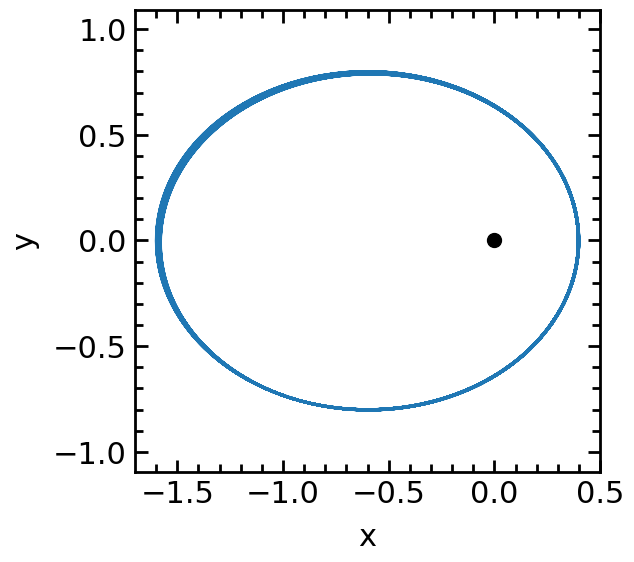

In [8]:
t_keppler, x_keppler, y_keppler, vx_keppler, vy_keppler = np.loadtxt("KQ_keppler-RK4.txt", comments="#", unpack=True)

plt.figure(figsize=(6,6))
plt.plot(x_keppler, y_keppler, lw=2)
plt.scatter([0], [0], color='black')
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.savefig("quydao_keppler.png", dpi=300)
plt.show()

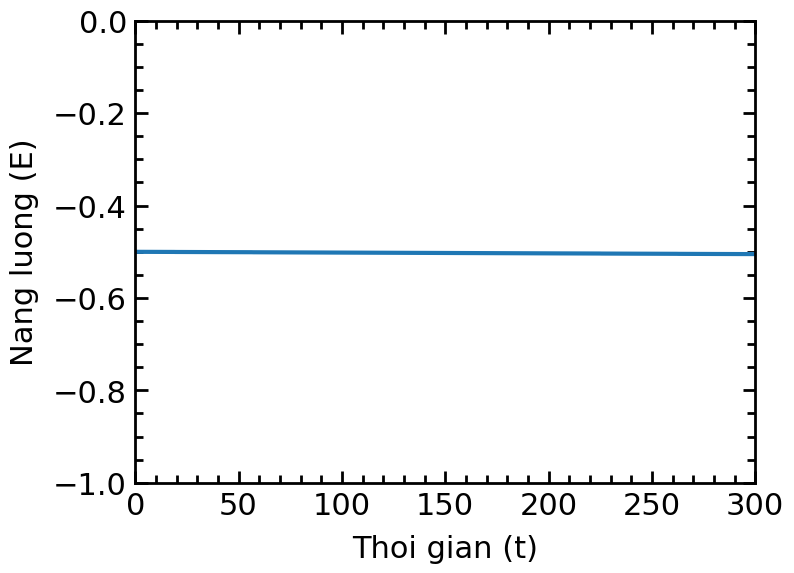

In [9]:
E_keppler = 1/2 * (vx_keppler**2 + vy_keppler**2) - 1/np.sqrt(x_keppler**2+y_keppler**2)
plt.figure(figsize=(8,6))

plt.plot(t_keppler, E_keppler, lw=3)

plt.xlabel("Thoi gian (t)")
plt.ylabel("Nang luong (E)")
plt.savefig("baotaon_NL_keppler.png", dpi=300)
plt.ylim(-1, 0)
plt.xlim(0,300)
plt.show()

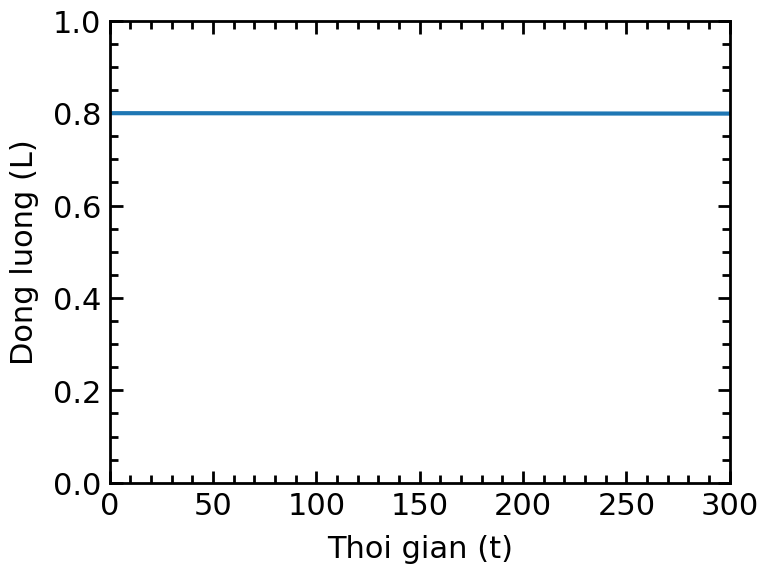

In [10]:
L_keppler = x_keppler*vy_keppler - y_keppler * vx_keppler
plt.figure(figsize=(8,6))

plt.plot(t_keppler, L_keppler, lw=3)

plt.xlabel("Thoi gian (t)")
plt.ylabel("Dong luong (L)")
plt.savefig("baotaon_MM_Dongluong_keppler.png", dpi=300)
plt.ylim(0, 1)
plt.xlim(0,300)
plt.show()